C:\Users\tomos\AppData\Local\Temp\ipykernel_28016\3545870465.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


Figure saved to: C:\Users\tomos\OneDrive - Ulster University\GlacialExtractionData\scripts\figure_scripts\Figure2\Figure2.png


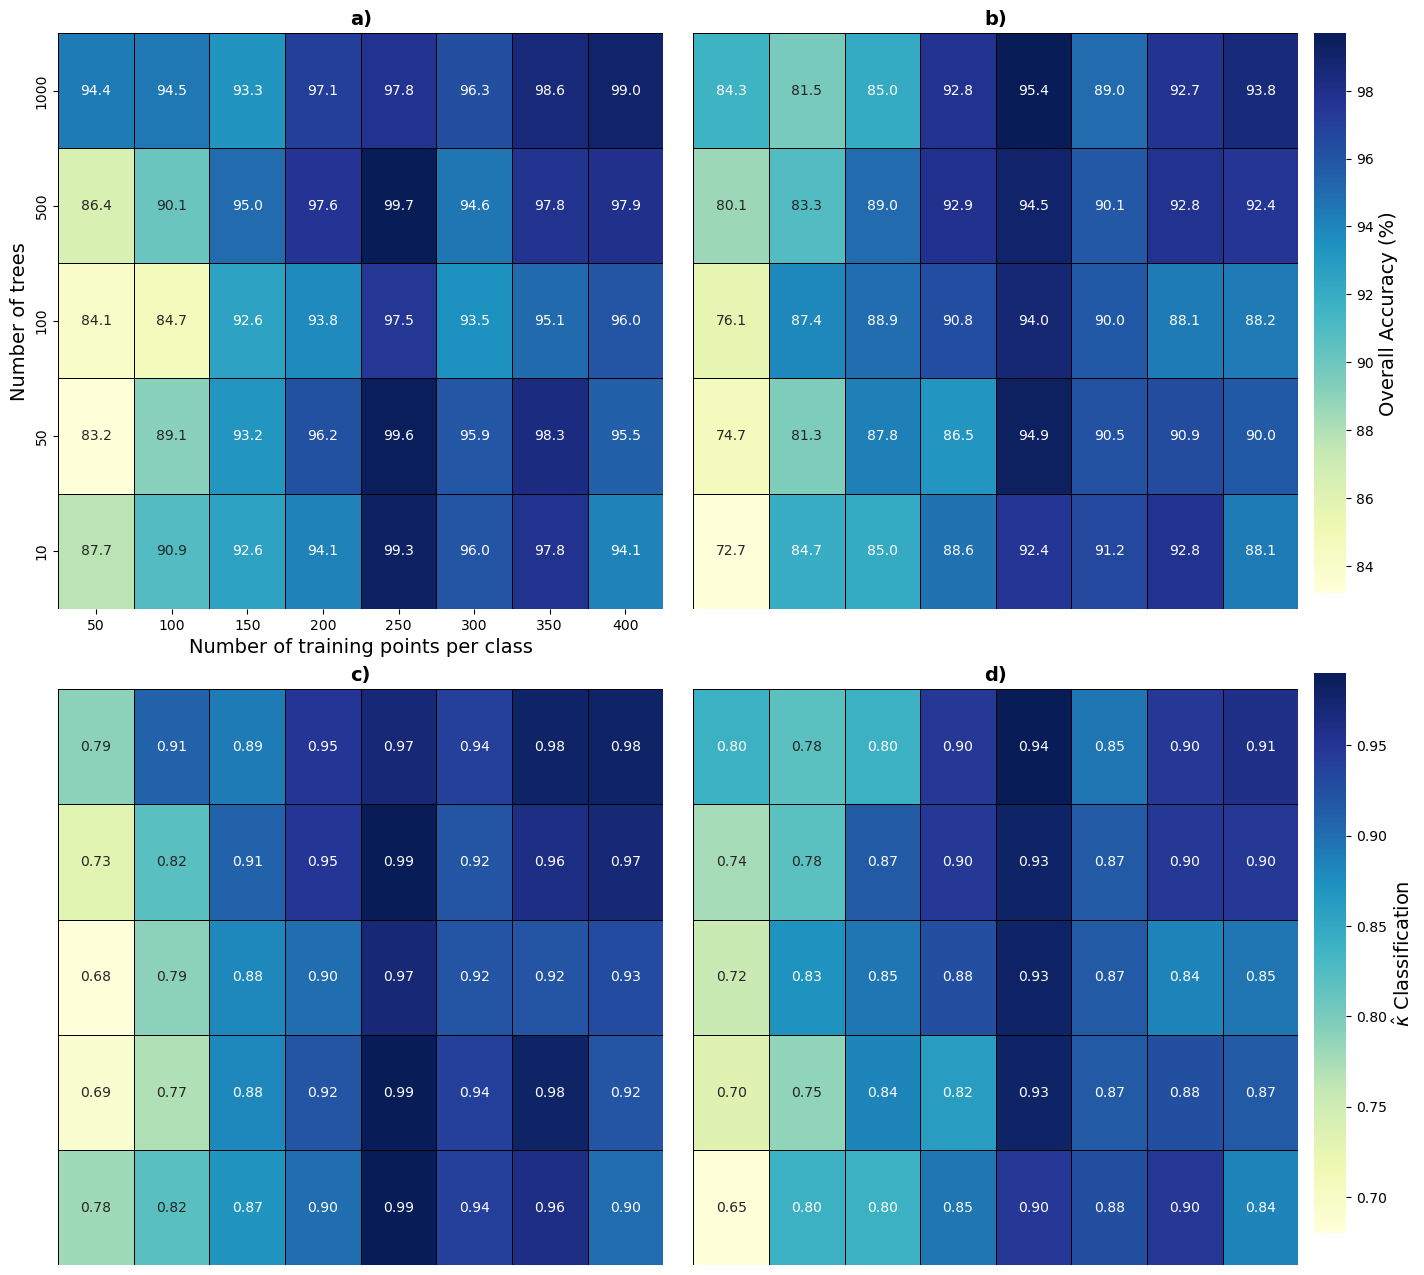

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

base_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()

file_path_wnw = os.path.join(base_dir, "WaterNotWaterResults.csv")
file_path_wc = os.path.join(base_dir, "WaterClassifierResults.csv")

save_path = os.path.join(base_dir, "Figure2.png")

df_wnw = pd.read_csv(file_path_wnw)
df_wc = pd.read_csv(file_path_wc)

heatmap_data_accuracy_wnw = df_wnw.pivot_table(index="RF", columns="Points", values="Overall accuracy (%)", aggfunc='mean')
heatmap_data_kappa_wnw = df_wnw.pivot_table(index="RF", columns="Points", values="Kappa hat classification", aggfunc='mean')

heatmap_data_accuracy_wc = df_wc.pivot_table(index="RF", columns="Points", values="Overall accuracy (%)", aggfunc='mean')
heatmap_data_kappa_wc = df_wc.pivot_table(index="RF", columns="Points", values="Kappa hat classification", aggfunc='mean')

heatmap_data_accuracy_wnw = heatmap_data_accuracy_wnw.sort_index(ascending=False)
heatmap_data_kappa_wnw = heatmap_data_kappa_wnw.sort_index(ascending=False)
heatmap_data_accuracy_wc = heatmap_data_accuracy_wc.sort_index(ascending=False)
heatmap_data_kappa_wc = heatmap_data_kappa_wc.sort_index(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 16), gridspec_kw={'wspace': 0.05, 'hspace': 0.14})

cbar_ax_accuracy = fig.add_axes([0.91, 0.53, 0.02, 0.35])
cbar_ax_kappa = fig.add_axes([0.91, 0.13, 0.02, 0.35])

# A)
sns.heatmap(
    heatmap_data_accuracy_wnw,
    annot=heatmap_data_accuracy_wnw.round(1),
    fmt=".1f",
    cmap="YlGnBu",
    ax=axes[0, 0],
    cbar=True,
    cbar_ax=cbar_ax_accuracy,
    cbar_kws={'label': 'Overall Accuracy (%)'},
    linecolor='black',
    linewidths=0.5
)
axes[0, 0].set_title('a)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Number of trees', fontsize=14)
axes[0, 0].set_xlabel('Number of training points per class', fontsize=14)

# B)
sns.heatmap(
    heatmap_data_accuracy_wc,
    annot=heatmap_data_accuracy_wc.round(1),
    fmt=".1f",
    cmap="YlGnBu",
    ax=axes[0, 1],
    cbar=False,
    linecolor='black',
    linewidths=0.5
)
axes[0, 1].set_title('b)', fontsize=14, fontweight='bold')

# C)
sns.heatmap(
    heatmap_data_kappa_wnw,
    annot=heatmap_data_kappa_wnw.round(2),
    fmt=".2f",
    cmap="YlGnBu",
    ax=axes[1, 0],
    cbar=True,
    cbar_ax=cbar_ax_kappa,
    cbar_kws={'label': 'Kappa Hat Classification'},
    linecolor='black',
    linewidths=0.5
)
axes[1, 0].set_title('c)', fontsize=14, fontweight='bold')

sns.heatmap(
    heatmap_data_kappa_wc,
    annot=heatmap_data_kappa_wc.round(2),
    fmt=".2f",
    cmap="YlGnBu",
    ax=axes[1, 1],
    cbar=False,
    linecolor='black',
    linewidths=0.5
)
axes[1, 1].set_title('d)', fontsize=14, fontweight='bold')

for ax in [axes[0, 1], axes[1, 0], axes[1, 1]]:
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.tick_params(left=False, bottom=False)

cbar_ax_accuracy.set_ylabel('Overall Accuracy (%)', fontsize=14)
cbar_ax_kappa.set_ylabel('$\hat{\kappa}$ Classification', fontsize=14)

plt.tight_layout(rect=[0, 0, 0.9, 1])

plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
print(f"Figure saved to: {save_path}")

plt.show()